<!-- Cabeçalho -->
<br />
<p align="center">

  <h1 align="center">Preparação da Base Geográfica do IBGE</h1>
</p>

# Introdução

A análise espacial depende da integração entre dados estatísticos e informações geográficas. Neste notebook, a base analítica construída durante o pré-processamento é integrada à malha territorial oficial das Unidades da Federação disponibilizada pelo Instituto Brasileiro de Geografia e Estatística (IBGE). O resultado desse processo é uma base geoespacial consolidada, utilizada posteriormente na construção dos mapas temáticos e demais análises espaciais do projeto.

# Objetivo

Preparar a base geográfica do projeto por meio da integração entre a malha territorial oficial do IBGE e a base demográfica previamente processada, gerando um GeoDataFrame consolidado para as análises espaciais.


# 1 Carregamento das dependências

In [11]:
# Importa a classe Path do módulo pathlib para manipulação de caminhos de arquivos e diretórios
from pathlib import Path 

# Importa a função PrepararBaseGeografica do módulo geospatial.geographic para preparar a base geográfica
from preprocessing.geospatial_processing import (
    PrepararBaseGeografica,
)

## 1.1 Definição dos caminhos do projeto

São definidos os diretórios utilizados para localizar a malha territorial oficial, a base demográfica processada e o diretório de saída da base geográfica consolidada.

In [12]:
ROOT = Path.cwd().parent.parent

# Caminho para o arquivo shapefile da malha geográfica dos estados
caminho_malha = (
    ROOT
    / "data"
    / "raw"
    / "BR_UF_2025"
    / "BR_UF_2025.shp"
)

# Caminho para o arquivo CSV contendo a base de estados
caminho_base_estados = (
    ROOT
    / "data"
    / "processed"
    / "df_estados.csv"
)

# Caminho para o diretório de saída onde os arquivos processados serão salvos
diretorio_saida = ROOT / "data" / "geo"

# Verifica se os arquivos e diretório existem
caminho_malha.exists(), caminho_base_estados.exists(), diretorio_saida.exists()

(True, True, True)

## 2 Instanciação da classe de preparação

Cria o objeto responsável por executar todas as etapas de integração entre a malha geográfica e a base demográfica.

In [13]:
# Instancia a classe PrepararBaseGeografica com os caminhos dos arquivos e diretório de saída
preparador = PrepararBaseGeografica(
    caminho_malha=caminho_malha,
    caminho_base_estados=caminho_base_estados,
)

## 2.1 Integração das bases e salvamento da base processada
 
Executa o processo de leitura, validação e integração entre a malha territorial do IBGE e os dados demográficos, produzindo um GeoDataFrame único para utilização nas análises espaciais. Ao final da execução, a base geográfica integrada é armazenada no diretório `data/geo`, tornando-se a fonte oficial para todas as análises espaciais desenvolvidas neste projeto.

In [14]:
# Executa o processo de preparação da base geográfica e salva os resultados no diretório de saída
gdf_estados = preparador.executar(
    diretorio_saida=diretorio_saida
)

gdf_regioes = preparador.base_regional # Prepara a base geográfica das regiões e salva os resultados no diretório de saída

# 3 Validação da Base de dados

## 3.1 Verificação da base gerada

Realiza uma inspeção inicial da estrutura do GeoDataFrame resultante para confirmar a correta integração entre os atributos demográficos e as geometrias das Unidades da Federação.

In [15]:
gdf_estados.head() # Exibe as primeiras linhas do GeoDataFrame resultante da preparação da base geográfica

,CD_UF,NM_UF,SIGLA_UF,CD_REGIAO,NM_REGIAO,SIGLA_RG,AREA_KM2,geometry,Indígenas 2010 Total,Indígenas 2010 Urbano,...,% Indígenas 2010 TI Urbano,% Indígenas 2010 TI Rural,% Indígenas 2010 Fora TI Urbano,% Indígenas 2010 Fora TI Rural,% Indígenas 2022 Urbano,% Indígenas 2022 Rural,% Indígenas 2022 TI Urbano,% Indígenas 2022 TI Rural,% Indígenas 2022 Fora TI Urbano,% Indígenas 2022 Fora TI Rural
0,43,Rio Grande do Sul,RS,4,Sul,S,281707.150,"MULTIPOLYGON (((-53.52154 -33.25881, -53.51825...",34001,14190,...,6.388919,93.611081,82.764538,17.235462,39.479807,60.520193,5.908166,94.091834,65.384238,34.615762
1,35,São Paulo,SP,3,Sudeste,SE,248219.485,"MULTIPOLYGON (((-48.03575 -25.35712, -48.03607...",41981,37917,...,14.672931,85.327069,95.657163,4.342837,87.506100,12.493900,0.071788,99.928212,94.649281,5.350719
2,32,Espírito Santo,ES,3,Sudeste,SE,46074.440,"MULTIPOLYGON (((-40.88385 -21.16198, -40.88384...",9585,6356,...,8.186356,91.813644,92.857143,7.142857,60.520472,39.479528,0.000000,100.000000,89.473684,10.526316
3,33,Rio de Janeiro,RJ,3,Sudeste,SE,43750.424,"MULTIPOLYGON (((-44.72025 -23.35934, -44.72029...",15894,15156,...,0.000000,100.000000,98.135198,1.864802,94.586325,5.413675,0.000000,100.000000,97.726167,2.273833
4,41,Paraná,PR,4,Sul,S,199293.571,"MULTIPOLYGON (((-48.40723 -25.84254, -48.40732...",26559,12509,...,0.000000,100.000000,85.531624,14.468376,40.461498,59.538502,0.000000,100.000000,74.380016,25.619984


In [16]:
gdf_regioes.head() # Exibe as primeiras linhas do GeoDataFrame das regiões resultante da preparação da base geográfica

,NM_REGIAO,geometry,Indígenas 2010 Total,Indígenas 2010 Urbano,Indígenas 2010 Rural,Indígenas 2010 TI Total,Indígenas 2010 TI Urbano,Indígenas 2010 TI Rural,Indígenas 2010 Fora TI Total,Indígenas 2010 Fora TI Urbano,Indígenas 2010 Fora TI Rural,Indígenas 2022 Total,Indígenas 2022 Urbano,Indígenas 2022 Rural,Indígenas 2022 TI Total,Indígenas 2022 TI Urbano,Indígenas 2022 TI Rural,Indígenas 2022 Fora TI Total,Indígenas 2022 Fora TI Urbano,Indígenas 2022 Fora TI Rural
0,Centro-oeste,"POLYGON ((-55.04062 -23.98082, -55.04429 -23.9...",143432,35156,108276,104019,2379,101640,39413,32777,6636,200153,75958,124195,114201,1771,112430,85952,74187,11765
1,Nordeste,"MULTIPOLYGON (((-46.01369 -10.24884, -46.01772...",232739,114401,118338,106142,19159,86983,126597,95242,31355,529128,329639,199489,129882,30200,99682,399246,299439,99807
2,Norte,"MULTIPOLYGON (((-60.80596 -13.65584, -60.81007...",342836,61565,281271,251891,2179,249712,90945,59386,31559,753780,376875,376905,316827,34974,281853,436953,341901,95052
3,Sudeste,"MULTIPOLYGON (((-48.03811 -25.35732, -48.03819...",99137,79272,19865,15904,652,15252,83233,78620,4613,123434,95348,28086,21525,1740,19785,101909,93608,8301
4,Sul,"MULTIPOLYGON (((-53.27272 -32.92798, -53.31016...",78773,34440,44333,39427,1594,37833,39346,32846,6500,88341,36926,51415,40409,1301,39108,47932,35625,12307


## 3.2 Validação visual 

Visualiza a malha geográfica consolidada para verificar se as geometrias foram carregadas corretamente e se a integração foi realizada sem inconsistências.

<Axes: >

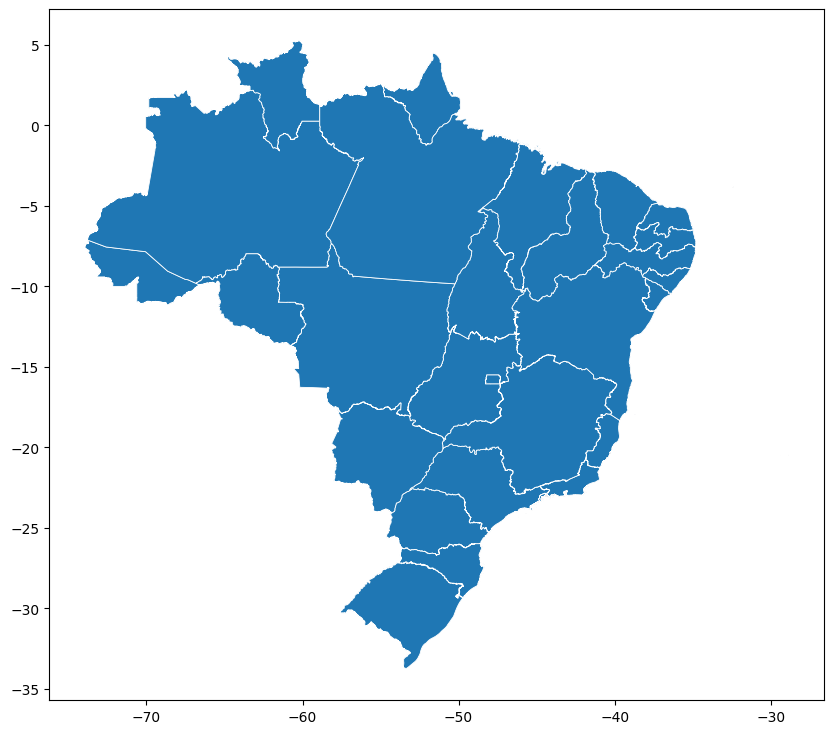

In [17]:
# Plota o GeoDataFrame resultante da preparação da base geográfica
gdf_estados.plot(
    figsize=(10, 10),
    edgecolor="white",
    linewidth=0.6
)

<Axes: >

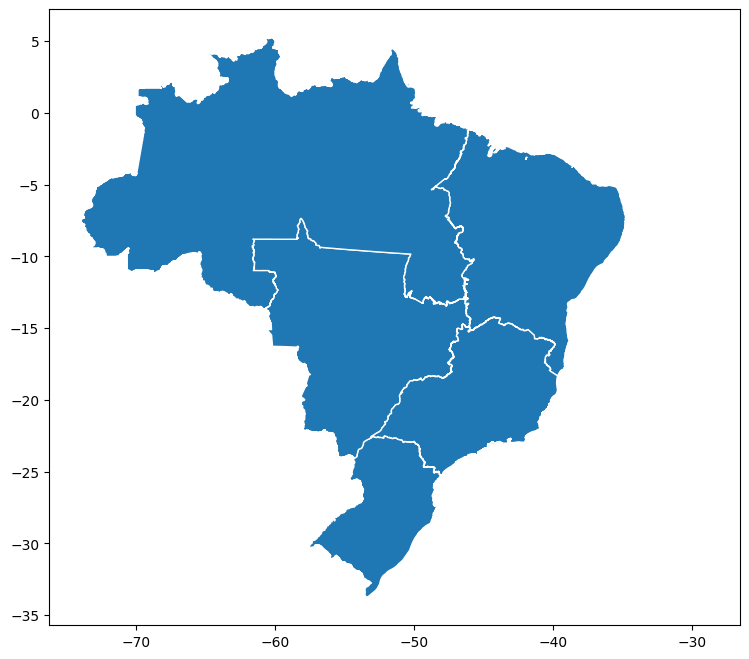

In [18]:
# Plota o GeoDataFrame das regiões com a população indígena total em 2022
gdf_regioes.plot(
    figsize=(10, 8),
    edgecolor="white",
    linewidth=1,
)

# 4. Síntese final

A integração entre a base demográfica e a malha territorial oficial foi concluída com sucesso, resultando em um GeoDataFrame consolidado contendo atributos estatísticos e informações espaciais das Unidades da Federação. Essa base servirá como insumo para a construção dos mapas temáticos apresentados na etapa de análise espacial.

# Informações da base gerada

In [19]:
gdf_estados.info() # Exibe informações sobre o GeoDataFrame, incluindo o número de entradas, colunas, tipos de dados e memória utilizada

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   CD_UF                            27 non-null     object  
 1   NM_UF                            27 non-null     object  
 2   SIGLA_UF                         27 non-null     object  
 3   CD_REGIAO                        27 non-null     object  
 4   NM_REGIAO                        27 non-null     object  
 5   SIGLA_RG                         27 non-null     object  
 6   AREA_KM2                         27 non-null     float64 
 7   geometry                         27 non-null     geometry
 8   Indígenas 2010 Total             27 non-null     int64   
 9   Indígenas 2010 Urbano            27 non-null     int64   
 10  Indígenas 2010 Rural             27 non-null     int64   
 11  Indígenas 2010 TI Total          27 non-null     int64   
 12  In

In [20]:
gdf_estados.crs # Exibe o sistema de referência de coordenadas (CRS) do GeoDataFrame

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [21]:
gdf_regioes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   NM_REGIAO                      5 non-null      object  
 1   geometry                       5 non-null      geometry
 2   Indígenas 2010 Total           5 non-null      int64   
 3   Indígenas 2010 Urbano          5 non-null      int64   
 4   Indígenas 2010 Rural           5 non-null      int64   
 5   Indígenas 2010 TI Total        5 non-null      int64   
 6   Indígenas 2010 TI Urbano       5 non-null      int64   
 7   Indígenas 2010 TI Rural        5 non-null      int64   
 8   Indígenas 2010 Fora TI Total   5 non-null      int64   
 9   Indígenas 2010 Fora TI Urbano  5 non-null      int64   
 10  Indígenas 2010 Fora TI Rural   5 non-null      int64   
 11  Indígenas 2022 Total           5 non-null      int64   
 12  Indígenas 2022 Urbano          5

In [22]:
gdf_regioes.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich